# Galactic Binaries with LISA: from Source to Parameter Estimation

**Goal.** Learn the steps of gravitational wave data analysis using a typical LISA source.

1. **The source**: what a galactic binary (GB) is, why we care, how its parameters map to a signal.
2. **The data**: LISA output = signal + noise.
3. **Detection/Search**: signal-to-noise ratio (SNR) and matched filtering (MF).
4. **Inference**: Bayes' theorem and fitting one source with the noise known.
5. **Extra**: what happens if we fit the noise as well.

Heavy lifting of the code lives in `GBEx_utils.py` that will be downloaded below. You can run all cells now!

You can run this notebook also on Colab: [GBExploration.ipynb](https://colab.research.google.com/github/coen-rondeel/gb-basics/blob/main/GBExploration.ipynb).

## Setup

Run the following install line only on Google Colab. Note that you may have to restart the session.

In [29]:
# Colab only: uncomment, run once, then Runtime -> Restart session
%pip install --upgrade pip && pip cache purge && pip install h5py corner healpy eryn lisaorbits segwo pytdi jaxgb lisaconstants ipywidgets jupyter "numpy==2.3.3" ipywidgets
# Colab: get the utils file next to the notebook (replace with the real URL of your repository)
!wget -q https://raw.githubusercontent.com/coen-rondeel/gb-basics/main/GBEx_utils.py
!wget -q https://raw.githubusercontent.com/coen-rondeel/gb-basics/main/VGB.hdf5

Files removed: 2 (40 kB)
Directories removed: 6


In [30]:
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

jax.config.update("jax_enable_x64", True)  # GW phases need float64

from GBEx_utils import *   # helpers: sources, GBAnalysis, priors, MCMC, plots

print("JAX devices:", jax.devices())

JAX devices: [CpuDevice(id=0)]


## Choose your Galactic Binary from Gaia

We use the catalog from Gaia described in this work [LISA Galactic binaries with astrometry from Gaia DR3](https://arxiv.org/abs/2302.12719) to choose a galactic binary with `SOURCE_NAME`.

In [31]:
# GBEx_utils reads VGB.hdf5 (SOURCES, VGB_RECORDS); h5py is only needed there.
print("VGB.hdf5 columns:", VGB_RECORDS.dtype.names)
print(f"{len(VGB_RECORDS)} verification binaries in the file")
print_sources_table()

VGB.hdf5 columns: ('Name', 'Amplitude', 'Frequency', 'FrequencyDerivative', 'EclipticLatitude', 'EclipticLongitude', 'Inclination', 'ErrorInclination', 'Polarization', 'InitialPhase', 'GalacticLatitude', 'GalacticLongitude', 'Period', 'Mass1', 'ErrorMass1', 'Mass2', 'ErrorMass2', 'Distance', 'ErrorDistance')
55 verification binaries in the file
name         type       f0 [mHz] fdot [1e-17] A [1e-23]  cos(i) dL [kpc]   lam   beta
HM Cnc       VGB           6.220       74.853      4.25    0.79     7.50  2.10  -0.08
ZTF J1539    VGB           4.822       25.378      9.40    0.10     2.47  3.58   1.15
ZTFJ2243     VGB           3.788       11.382     12.22    0.14     1.76  0.23   0.94
V407Vul      VGB           3.512        8.282      9.38    0.50     2.09  5.15   0.82
ES Cet       VGB           3.225       -1.660      9.52    1.05     1.78  0.43  -0.35
SDSS J0651   VGB           2.614        2.631     15.77    0.05     0.96  1.77   0.10
ZTFJ0127     VGB           2.431        2.190     1

In [32]:
SOURCE_NAME = "ZTF J1539"   # try: "ZTF J1539", "SDSS J0651", "ES Cet", "Synthetic 1", ...

## Where are the sources on the sky?

The map shows every verification binary in the catalog in equatorial coordinates, together with the Galactic plane, Galactic centre, and currently selected source. This matches the equatorial projection used in Fig. 5 of [LISA Galactic binaries with astrometry from Gaia DR3](https://arxiv.org/abs/2302.12719).

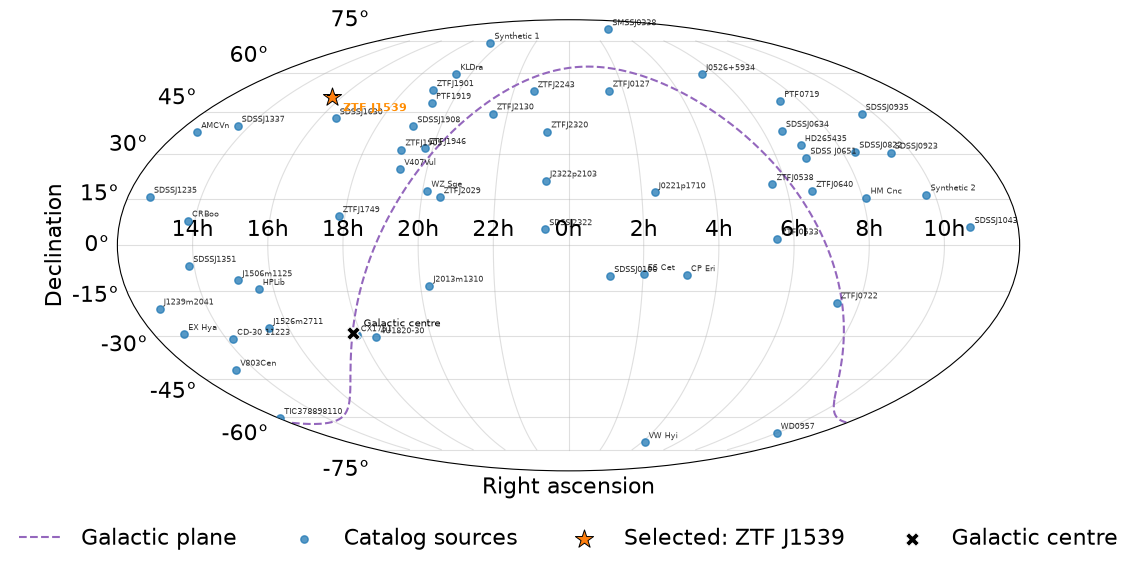

In [33]:
sky_names = list(SOURCES)
sky_lambdas = np.array([SOURCES[name]["lam"] for name in sky_names])
sky_betas = np.array([SOURCES[name]["beta"] for name in sky_names])
sky_ra, sky_dec = ecliptic_to_equatorial(sky_lambdas, sky_betas)
sky_x = (sky_ra + np.pi) % (2 * np.pi) - np.pi

gal_lon_ecl, gal_lat_ecl, gc_lon_ecl, gc_lat_ecl = galactic_plane_ecliptic()
gal_lon, gal_lat = ecliptic_to_equatorial(gal_lon_ecl, gal_lat_ecl)
gc_lon, gc_lat = ecliptic_to_equatorial(gc_lon_ecl, gc_lat_ecl)
gal_x = (gal_lon + np.pi) % (2 * np.pi) - np.pi
gal_x[np.abs(np.diff(gal_x, prepend=gal_x[0])) > np.pi] = np.nan
fig, ax = plt.subplots(figsize=(13, 6), subplot_kw={"projection": "mollweide"})
ax.plot(gal_x, gal_lat, color="tab:purple", ls="--", lw=1.5, label="Galactic plane")
ax.scatter(sky_x, sky_dec, s=28, color="tab:blue", alpha=0.75, label="Catalog sources", zorder=3)

for name, x, dec in zip(sky_names, sky_x, sky_dec):
    if name != SOURCE_NAME:
        ax.annotate(name, (x, dec), xytext=(3, 3), textcoords="offset points", fontsize=5.5, alpha=0.8)

selected = SOURCES[SOURCE_NAME]
selected_ra, selected_dec = ecliptic_to_equatorial(selected["lam"], selected["beta"])
selected_x = (selected_ra + np.pi) % (2 * np.pi) - np.pi
ax.scatter(selected_x, selected_dec, marker="*", s=190, color="tab:orange",
           edgecolor="black", linewidth=0.7, label=f"Selected: {SOURCE_NAME}", zorder=5)
ax.annotate(SOURCE_NAME, (selected_x, selected_dec), xytext=(8, -10), textcoords="offset points",
            fontsize=8, fontweight="bold", color="darkorange")
gc_x = (gc_lon + np.pi) % (2 * np.pi) - np.pi
ax.scatter(gc_x, gc_lat, marker="X", s=100, color="black", edgecolor="white",
           linewidth=0.8, label="Galactic centre", zorder=6)
ax.annotate("Galactic centre", (gc_x, gc_lat), xytext=(8, 5), textcoords="offset points",
            fontsize=7, color="black")

tick_degrees = np.arange(-150, 151, 30)
ax.set_xticks(np.radians(tick_degrees))
ax.set_xticklabels([f"{(int(degree) % 360) // 15}h" for degree in tick_degrees])
ax.set_xlabel("Right ascension")
ax.set_ylabel("Declination")
ax.grid(True, alpha=0.4)
ax.legend(loc="lower center", bbox_to_anchor=(0.5, -0.22), ncol=4, frameon=False)
fig.tight_layout()
plt.show()

In [34]:
# Parameters of the selected source: these are what get_source() feeds to the rest of the notebook
raw_name = SOURCES[SOURCE_NAME].get("raw_name")
if raw_name is not None:
    print("Raw VGB.hdf5 record:\n", VGB_RECORDS[VGB_RECORDS["Name"] == raw_name.encode()][0], "\n")
for label, value in zip(PARAM_NAMES, get_source(SOURCE_NAME)):
    print(f"{label:>6} = {value:.8e}")

Raw VGB.hdf5 record:
 (b'ZTFJ1539', 9.402415441563617e-23, 0.004821699107149872, 2.53782494976533e-16, 1.1547376242549767, 3.578406556800828, 1.4686945655532282, 0.605, 0.0, 0.0, 0.8828206969145198, 1.4097827219814119, 414.7915404, 0.61, 0.0195, 0.21, 0.015, 2469.0, 1253.0) 

    f0 = 4.82169911e-03
  fdot = 2.53782495e-16
     A = 9.40241544e-23
  beta = 1.15473762e+00
lambda = 3.57840656e+00
   psi = 7.85398163e-01
  iota = 1.46869457e+00
  phi0 = 1.04719755e+00


# 1. The source: a galactic binary

## What is it, where is it, why do we care?

A galactic binary is a pair of compact stars orbiting each other in the Milky Way
with periods of minutes to hours. They emit gravitational waves (GWs) at twice the orbital frequency:

$$f_0 = \frac{2}{P_{\rm orb}} \sim 0.1 - 10\,\mathrm{mHz},$$

right in the LISA band. Why do we care?

* **Millions of them**: LISA will individually resolve on the order of $10^4$ binaries and see the rest as a confusion foreground that must be modeled to find other sources.
* **Verification binaries**: known systems seen in light (e.g. by Gaia, ZTF) that LISA should be able to see.
* **Astrophysics**: masses, distances, mass transfer, tides, triple systems, and the structure of the Galaxy.
* **Not only white dwarf binaries**: galactic binary populations also include systems hosting one or more neutron stars or black holes

## From physical properties to the signal

Over LISA's lifetime a circular binary is almost monochromatic. Eight numbers describe the signal:

| Parameter | Meaning | Physical origin |
|---|---|---|
| $f_0$ | GW frequency | $2/P_{\rm orb}$ |
| $\dot f_0$ | frequency drift | GW radiation reaction ($\mathscr{M}_c$), mass transfer |
| $\mathscr{A}$ | amplitude | $\propto \mathscr{M}_c^{5/3} f_0^{2/3} / d_L$ |
| $\beta, \lambda$ | ecliptic latitude, longitude | sky position |
| $\iota$ | inclination | orientation of the orbit |
| $\psi$ | polarization angle | orientation on the sky |
| $\phi_0$ | initial phase | orbital phase at $t_0$ |

With $\mathscr{M}_c = (m_1 m_2)^{3/5}/(m_1+m_2)^{1/5}$:

$$\mathscr{A} = \frac{2 (G\mathscr{M}_c)^{5/3} (\pi f_0)^{2/3}}{c^4 d_L},\qquad
\dot f_{\rm GW} = \frac{96}{5}\pi^{8/3}\left(\frac{G\mathscr{M}_c}{c^3}\right)^{5/3} f_0^{11/3}.$$

If $\dot f_0$ is measured and driven by GWs only, it fixes $\mathscr{M}_c$ and therefore the distance: $d_L = \frac{5c}{48\pi^2}\frac{\dot f_{\rm GW}}{f_0^3\mathscr{A}}$.

In [35]:
physical_summary(SOURCE_NAME)

ZTF J1539: m1=0.61 Msun, m2=0.21 Msun, dL=2.469 kpc, f0=4.822 mHz
  chirp mass            : 0.303 Msun
  fdot (GW-driven)      : 2.538e-16 Hz/s   (table: 2.538e-16)
  amplitude from Mc, dL : 9.402e-23      (table: 9.402e-23)
  dL from (fdot, f0, A) : 2.47 kpc        (table: 2.469)


**Question.** Why are some of these sources interesting for LISA? Look at the frequency, the amplitude, and the sign of $\dot f$ in the table.

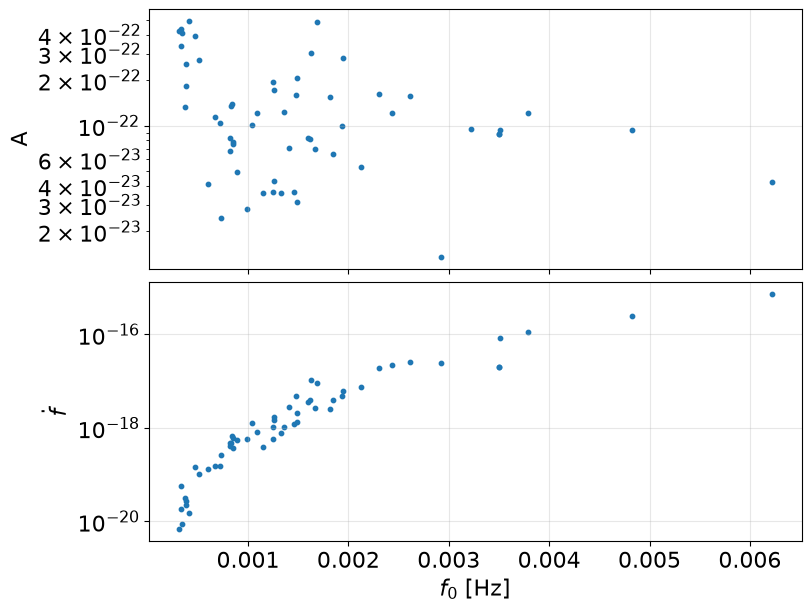

In [36]:
# Extract values
f0 = np.array([v["f0"] for v in SOURCES.values()])
A = np.array([v["A"] for v in SOURCES.values()])
fdot = np.array([v["fdot"] for v in SOURCES.values()])

# Sort by frequency for cleaner plotting
idx = np.argsort(f0)
f0 = f0[idx]
A = A[idx]
fdot = fdot[idx]

# Create subplots
fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(8, 6),
    sharex=True,
    constrained_layout=True
)

# Amplitude subplot
ax1.scatter(f0, A, s=10)
ax1.set_ylabel("A")
ax1.set_yscale("log")
ax1.grid(True, alpha=0.3)

# Frequency derivative subplot
ax2.scatter(f0, fdot, s=10)
ax2.set_xlabel(r"$f_0$ [Hz]")
ax2.set_ylabel(r"$\dot f$")
ax2.set_yscale("log")
ax2.grid(True, alpha=0.3)

plt.show()


## The wave itself

In the source frame the two polarizations are (with $\Phi(t)=-\phi_0+2\pi f_0 t + \pi \dot f_0 t^2$)

$$h_+ = \mathscr{A}(1+\cos^2\iota)\cos\Phi(t),\qquad h_\times = 2\mathscr{A}\cos\iota\,\sin\Phi(t).$$

Face-on ($\iota=0$) gives circular polarization; edge-on ($\iota=\pi/2$) gives purely linear polarization.

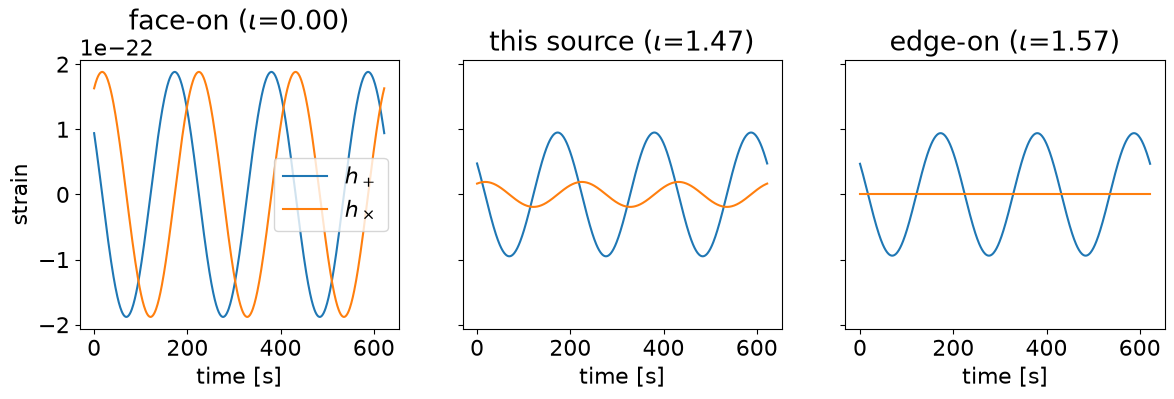

In [37]:
src = get_source(SOURCE_NAME)
t = np.linspace(0, 3 / src[0], 600)   # 3 GW cycles
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5), sharey=True)
for ax, iota, lab in zip(axes, [0.0, src[6], np.pi / 2], ["face-on", "this source", "edge-on"]):
    hp_, hx_ = strain_polarizations(t, src[0], src[1], src[2], iota, src[7])
    ax.plot(t, hp_, label=r"$h_+$"); ax.plot(t, hx_, label=r"$h_\times$")
    ax.set_title(f"{lab} ($\\iota$={iota:.2f})"); ax.set_xlabel("time [s]")
axes[0].set_ylabel("strain"); axes[0].legend()
plt.show()

## Orientation and the two polarizations

A gravitational wave stretches space transversely to its direction of travel. For a ring of free masses facing the source:

* $h_+$ stretches along one axis while squeezing along the perpendicular one (the "+" pattern);
* $h_\times$ does the same along axes rotated by $45^\circ$.

The inclination $\iota$ is the angle between the orbital axis and the line of sight to LISA. It sets the mix of the two polarizations:

* **Face-on** ($\cos\iota=\pm1$): $h_+$ and $h_\times$ have equal amplitude and are $90^\circ$ out of phase. The stretching axis rotates with the orbit, once per orbit. We see a circular wave.
* **Edge-on** ($\cos\iota=0$): only $h_+$ survives, the axis stays fixed and the wave is linear, with half the amplitude of the face-on case.

A single LISA arm only feels the component of the stretching along its own direction, $\Delta L/L=\tfrac12\,[h_+\cos2\alpha+h_\times\sin2\alpha]$, where $\alpha$ is the angle between the arm and the $+$ axis. The red arm below does this: it oscillates at **twice the orbital frequency** because the stretching pattern repeats after half an orbit.

The animation shows the binary in 3D, the same orbit as seen from LISA, the ring and arm (strain strongly exaggerated), and the resulting strains over one orbit.

In [38]:
from IPython.display import display

# Use the play controls under the figure; psi rotates the polarization axes, arm_angle sets the arm direction
display(animate_binary_gw(cos_iota=np.cos(src[6]), psi=src[5], arm_angle=0.0))

**Try it:** change the inclination, polarization angle and arm direction, then press *Run Interact* to render a new animation.

* Set $\cos\iota=\pm1$: does the red arm still oscillate? Does its amplitude depend on the arm direction?
* Set $\cos\iota=0$: which arm directions see the largest and the smallest signal? What happens at $\alpha-\psi=\pm45^\circ$?
* Flip the sign of $\cos\iota$: what changes in the orbit seen from LISA, and what changes in the ring?

In [39]:
interactive_binary_animation()

interactive(children=(FloatSlider(value=0.79, description='cos(iota)', max=1.0, min=-1.0, step=0.05), FloatSli…

### TDI combinations

The six links contain enormous laser-frequency noise. Time-Delay Interferometry (TDI) combines delayed copies of the link measurements so that the laser noise cancels (to the accuracy of the chosen TDI generation). A simplified map of the signal path is

$$ (h_+,h_\times)\;\xrightarrow{\,\text{LISA link response}\,}\;(y_1,\ldots,y_6)\;\xrightarrow{\,\text{delayed TDI combinations}\,}\;(X,Y,Z)\;\xrightarrow{\,\text{orthogonal channel rotation}\,}\;(A,E,T). $$

For this tutorial's normalization, the final rotation is

$$A=\frac{Z-X}{\sqrt2},\qquad E=\frac{X-2Y+Z}{\sqrt6},\qquad T=\frac{X+Y+Z}{\sqrt3}.$$
`compute_strain2x` is a utility helper that composes `segwo`'s strain-to-link response with `pytdi`'s link-to-TDI mixing. It is **not** called by the notebook's `GBAnalysis` injection. The notebook instead uses `MyJaxGB`, which calls `jaxgb.get_tdi` configured for second-generation TDI and the AET combination. These are distinct implementations of the response. In either route, the template returned to the notebook is already frequency-domain A, E and T data, not $h_+$ and $h_\times$ and not raw link measurements. For a detailed description, see the [Appendix: From polarizations to the detector output](#appendix-from-polarizations-to-the-detector-output).

Besides JaxGB, there are other widely-used packages available generate GB signal templates. Examples are: GBGPU, FastGB, and eGB-multi. The initial version of GBGPU and JaxGB are based on the fast frequency domain signal generation methods of FastGB. However, recently developers are improving these packages to include more realism into the signal templates. For example, eGB-multi, a package based on JaxGB, specifically designed for eccentric galactic binaries.


In [40]:
source_params = get_source(SOURCE_NAME)

In [41]:
tobs = 365 * 86400  # 365 days
analysis = GBAnalysis(source_params,tobs=tobs)
print(f"T_obs = {analysis.tobs/86400:.1f} days, df = {analysis.df:.2e} Hz, {analysis.n_bins} frequency bins around f0")
print("Optimal SNR of the injection:", round(analysis.optimal_snr(analysis.signal), 1))

T_obs = 365.0 days, df = 3.17e-08 Hz, 128 frequency bins around f0
Optimal SNR of the injection: 47.5


**Try it:** move the sliders. Which parameters change the *overall power* in A, E, T, and which change how it is *shared* between channels or *shaped* in frequency?

In [42]:
interactive_waveform_explorer(analysis)

interactive(children=(FloatSlider(value=0.10192445579505019, description='cos(iota)', max=1.0, min=-1.0, step=…

# 2. The data: signal + noise

$$d(t) = h(t;\boldsymbol\theta) + n(t).$$

We work in the frequency domain. The noise is Gaussian and described by its one-sided power spectral density $S_n(f)$:
in each frequency bin of width $\Delta f = 1/T_{\rm obs}$ the complex noise has variance $S_n(f)/(2\Delta f)$.
(The instrument noise itself is covered in the previous tutorial.)

### Instrument noise and the simulated data

The noise model starts with optical-metrology (OMS) displacement noise and test-mass (TM) acceleration noise, modeled as independent sources on the links. `compute_covariance` converts their reference spectra to fractional-frequency units, builds the link-noise covariance, and projects it through the delayed TDI mixing into the A/E/T basis. The covariance is averaged over ten orbit-time samples to obtain an approximately stationary frequency-dependent matrix $\mathbf C_{AET}(f)$.

For each frequency bin, the code draws a complex Gaussian channel vector:

$$\mathbf n_k=\mathbf L_k\mathbf z_k,\qquad
\mathbf L_k\mathbf L_k^\dagger=\frac{\mathbf C_{AET}(f_k)}{2\Delta f},\qquad
\mathbf z_k\sim{N}(\mathbf 0,\mathbf I).$$

Thus $\mathbb{E}[\mathbf n_k\mathbf n_k^\dagger]=\mathbf C_{AET}(f_k)/(2\Delta f)$. The Cholesky factor preserves any A/E/T correlations in a bin; independent draws are made for different frequency bins. The simulated observation is

$$\mathbf d_k=\mathbf s_{AET,k}+\mathbf n_k.$$

This is a **frequency-domain toy observation**, not a time series that is Fourier transformed. The tutorial assumes equal-arm second-generation TDI, averages the changing noise covariance over time, neglects correlations between frequency bins, and uses the diagonal PSD in the main likelihood. Because we are assuming equal armlength orbits, these assumption hold up quite well. But, even in this simplified scenario, the generated noise can retain small cross-channel correlations even though the likelihood ignores them. In reality, the orbits will have unequal and changing armlengths and an unresolved-binary foreground that would break these assumptions, all requiring a more complete model.



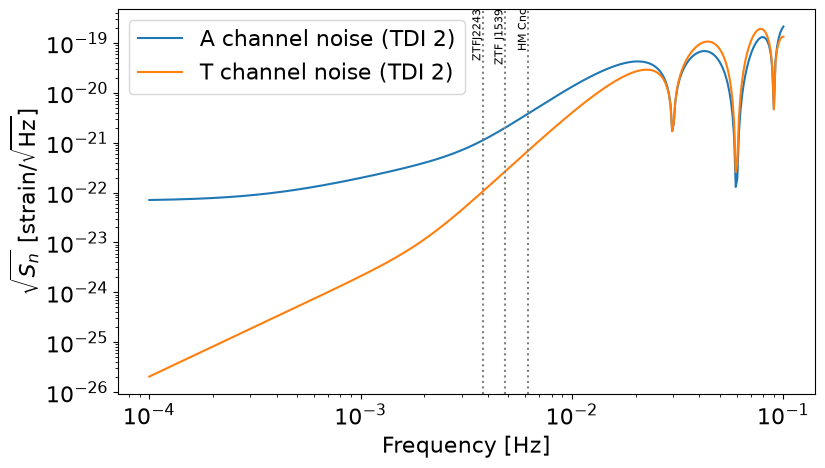

In [43]:
show_n_gbs = 3 # change if you want to show more or fewer sources in the noise curve plot
plot_noise_curve(analysis, source_names=list(SOURCES)[:show_n_gbs])

Each source sits at its own frequency, where the noise level is different. Zooming in on the injected source:

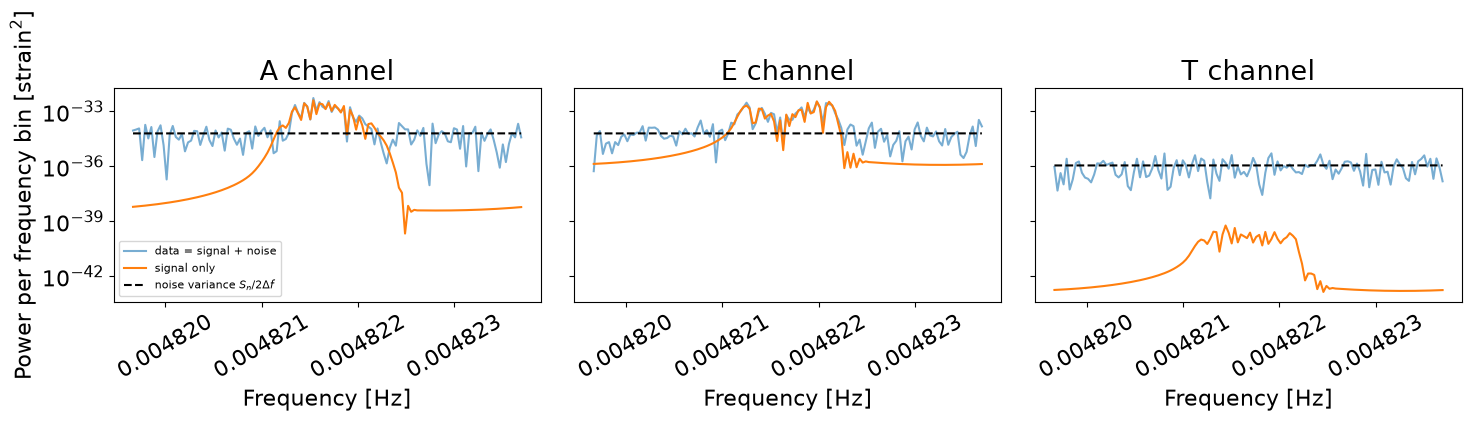

In [44]:
analysis.plot_data()

Different sources have visibly different shapes: the amplitude modulation from LISA's motion is stronger for higher $f_0$ and for sources near the ecliptic plane.

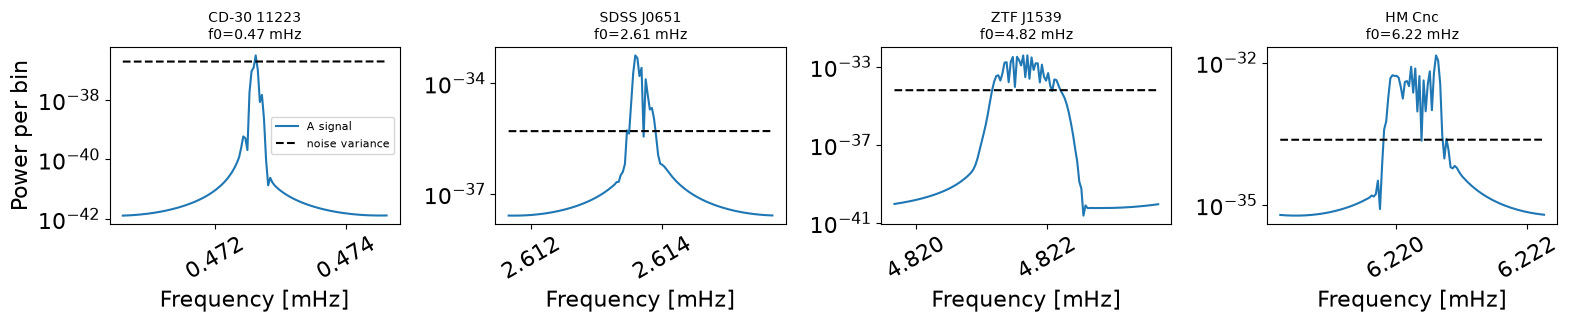

In [45]:
plot_reference_sources(["CD-30 11223", "SDSS J0651", "ZTF J1539", "HM Cnc"])

**Optional: noise structure.** In the AET basis the cross-spectral matrix (CSD) is almost diagonal, so we can treat A, E, T independently.

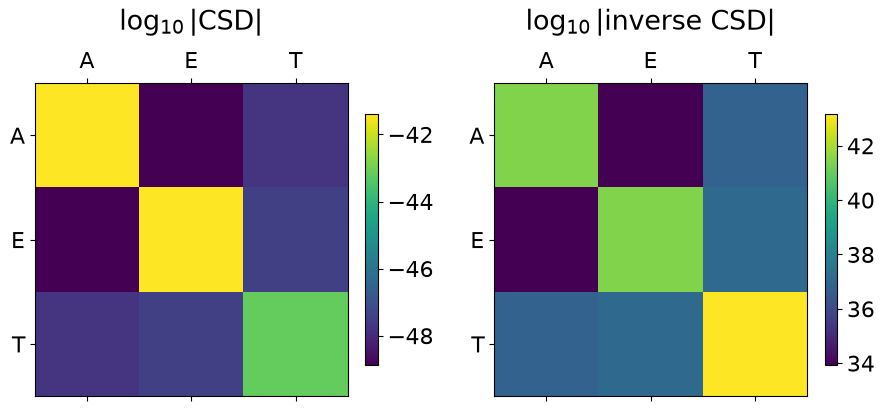

In [46]:
analysis.plot_covariance_structure()

The inverse $TT$-component of the CSD is larger than the other diagonal components. Can you explain why the $TT$-component was often ignored in analyses that assumed equal armlength orbits?

# 3. Signal-to-noise ratio and matched filtering

For a template $h$, the noise-weighted inner product is

$$\langle a | b\rangle = 4\Delta f\ \mathrm{Re}\sum_{X\in\{A,E,T\}}\sum_k  \tilde a_X^*(f_k)\,C^{-1}_{XX'}(f_k)  \tilde b_{X'}(f_k).$$

* **Intrinsic (optimal) SNR**: $\rho_{\rm opt}=\sqrt{\langle h|h\rangle}$. How loud the source is in this noise.
* **Matched-filter SNR** on data $d$: $\rho_{\rm MF}=\langle d|h\rangle/\sqrt{\langle h|h\rangle}$. On signal + noise it is a Gaussian with mean $\rho_{\rm opt}$ and unit variance.

optimal SNR           : 47.49
matched-filter SNR    : 47.23   (this noise realization)


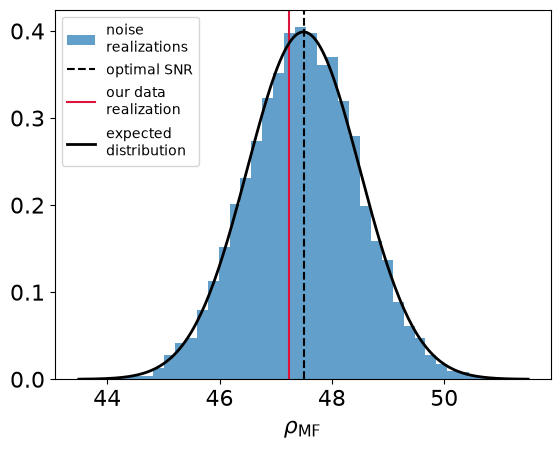

mean = 47.49, std = 0.99  (expected: 47.49, 1.00)


In [47]:
rho_opt = analysis.optimal_snr(analysis.signal)
rho_mf = float(analysis.matched_filter_snr(analysis.data, analysis.signal))
print(f"optimal SNR           : {rho_opt:.2f}")
print(f"matched-filter SNR    : {rho_mf:.2f}   (this noise realization)")

rho_many = analysis.snr_realizations(n_real=10000)
plt.hist(rho_many, bins=40, density=True, alpha=0.7, label="noise \nrealizations")
# gaussian with mean=optimal SNR, std=1.0
x = np.linspace(rho_opt - 4, rho_opt + 4, 200)
plt.axvline(rho_opt, color="k", ls="--", label="optimal SNR")
plt.axvline(rho_mf, color="crimson", label="our data \nrealization")
plt.plot(x, 1 / np.sqrt(2 * np.pi) * np.exp(-0.5 * (x - rho_opt) ** 2), color="k", lw=2, label="expected \ndistribution")
plt.xlabel(r"$\rho_{\rm MF}$");
plt.legend(loc="upper left", fontsize=10);
plt.show()
print(f"mean = {rho_many.mean():.2f}, std = {rho_many.std():.2f}  (expected: {rho_opt:.2f}, 1.00)")

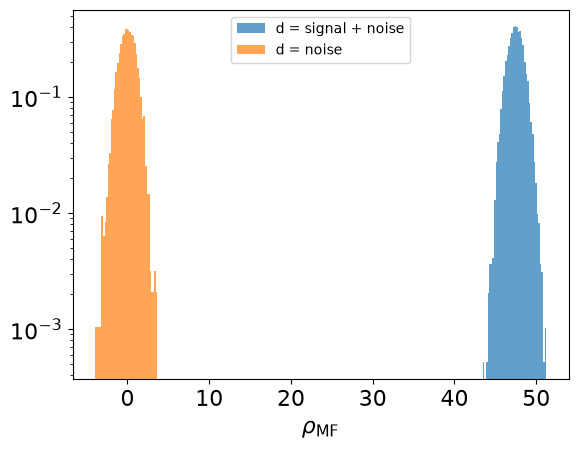

In [48]:
rho_mf_noise = float(analysis.matched_filter_snr(analysis.data-analysis.signal, analysis.signal))
rho_many_noise = np.asarray(analysis.matched_filter_snr(analysis.draw_noise(np.random.default_rng(2601), size=(5000,))[..., analysis.window], analysis.signal))
plt.hist(rho_many, bins=40, density=True, alpha=0.7, label="d = signal + noise", log=True)
plt.hist(rho_many_noise, bins=40, density=True, alpha=0.7, label="d = noise", log=True)
plt.xlabel(r"$\rho_{\rm MF}$");
plt.legend(loc="upper center", fontsize=10);
plt.show()

## SNR across frequency

We shift the template frequency by a few bins and recompute the SNRs. The matched-filter SNR peaks at the true frequency, and its width tells us how precisely $f_0$ can be measured, of order a few $\Delta f$.

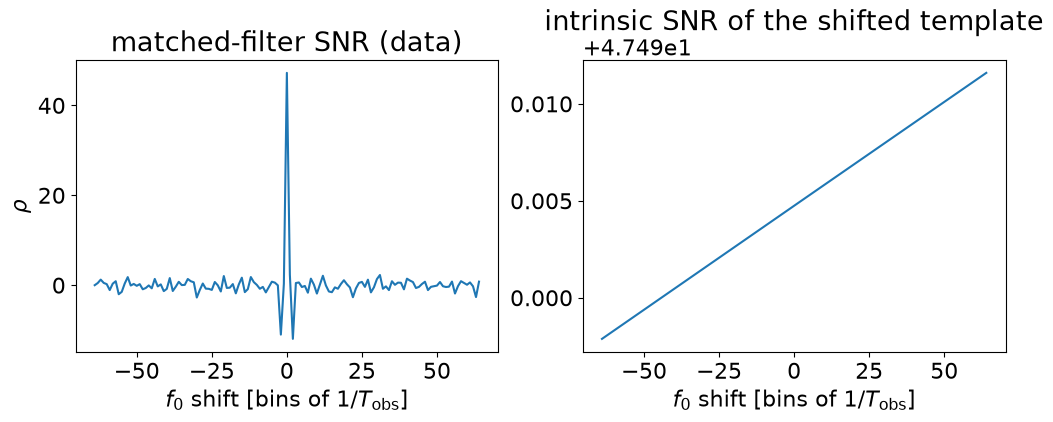

In [49]:
offsets = np.arange(-analysis.pad, analysis.pad + 1)
mf_f, opt_f = analysis.snr_vs_frequency(offsets)
f_scan = analysis.source_params[0] + offsets * analysis.df

fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
ax[0].plot(offsets, mf_f); ax[0].set_title("matched-filter SNR (data)")
ax[1].plot(offsets, opt_f); ax[1].set_title("intrinsic SNR of the shifted template")
for a in ax: a.set_xlabel(r"$f_0$ shift [bins of $1/T_{\rm obs}$]")
ax[0].set_ylabel(r"$\rho$"); plt.show()

## SNR across the sky

We keep every parameter but $(\beta,\lambda)$ fixed and scan the sky with a HEALPix grid (low resolution for speed).

* The **intrinsic SNR** map says where on the sky the same source would be louder or quieter, which is the antenna pattern and the orbital modulation.
* The **matched-filter SNR** map on our data shows where the injected source is located.

**Note that these new sky localization variables differ from the previously shown** in Fig. 5 of [LISA Galactic binaries with astrometry from Gaia DR3](https://arxiv.org/abs/2302.12719).

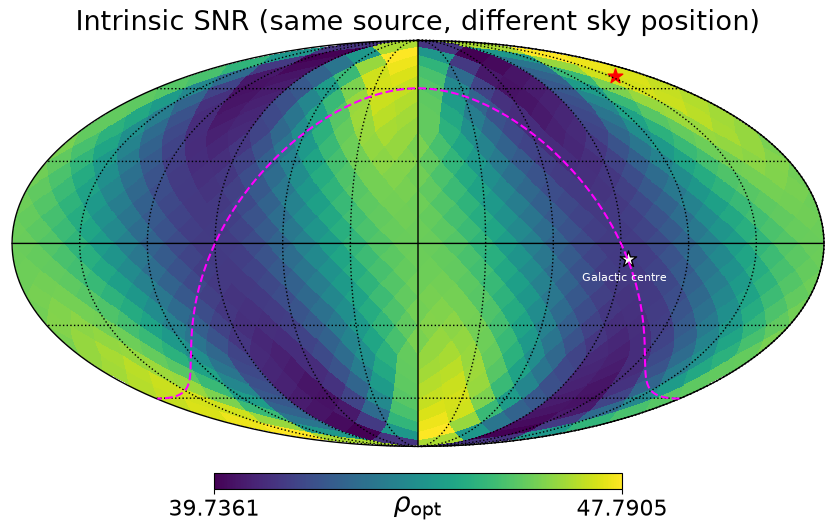

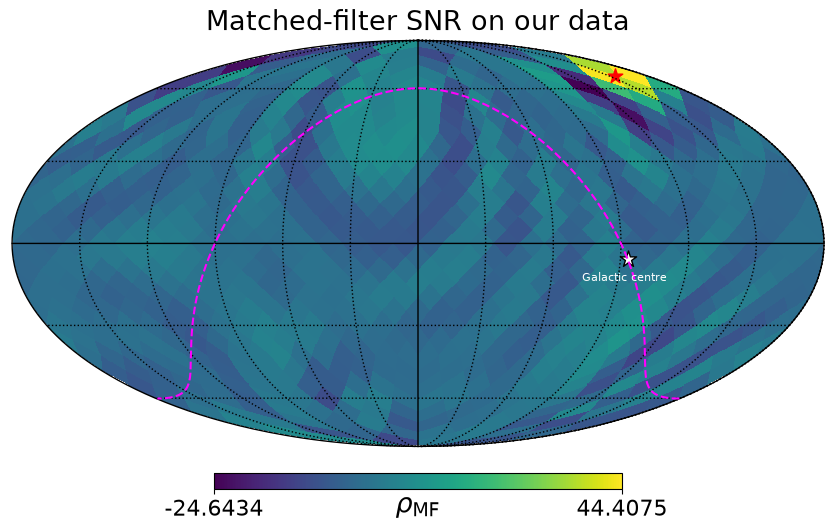

In [50]:
NSIDE_SCAN = 8   # 768 pixels; increase for sharper maps (slower)
mf_sky, opt_sky = analysis.snr_vs_sky(nside=NSIDE_SCAN)
truth_sky = (analysis.source_params[3], analysis.source_params[4])
plot_sky_map(opt_sky, "Intrinsic SNR (same source, different sky position)", r"$\rho_{\rm opt}$", truth=truth_sky)
plot_sky_map(mf_sky, "Matched-filter SNR on our data", r"$\rho_{\rm MF}$", truth=truth_sky)

**Questions.** Is the best-matching pixel the true one? Why is the matched-filter map broad when the SNR is low?

In [51]:
interactive_sky_snr(analysis, nside=NSIDE_SCAN)

Sliders mode. For click-to-select run `%matplotlib widget` first (needs ipympl).


interactive(children=(FloatSlider(value=1.1547376242549767, description='beta', max=1.5707963267948966, min=-1…

# 4. Inference: Likelihood, priors and fitting one GB (known noise)

Bayes' theorem:

$$p(\boldsymbol\theta|d) = \frac{p(d|\boldsymbol\theta)\,\pi(\boldsymbol\theta)}{p(d)}.$$

For Gaussian noise the log-likelihood is

$$\ln p(d|\boldsymbol\theta) = -\tfrac12\langle d-h(\boldsymbol\theta)\,|\,d-h(\boldsymbol\theta)\rangle + {\rm const.}$$

where the inner product $\langle \cdot | \cdot \rangle$ was introduced in [the SNR section](#3.-Signal-to-noise-ratio-and-matched-filtering).

The constant (the noise determinant) is dropped because the noise is assumed to be known and fixed. We will see how to fit for the noise as well in the last section.

Before sampling, two sanity checks: the template at the true parameters must match the injection (mismatch $\approx 0$), and moving $f_0$ away must lower $\ln p(d|\boldsymbol\theta)$.

In [52]:
loglike = analysis.make_log_likelihood(fit_noise=False)
truth = analysis.source_params.copy()
zero_amp_parameters = truth.copy(); zero_amp_parameters[2] = 0.0

h_true = analysis.template(analysis.source_params)
print("mismatch(template, injection):", mismatch(h_true, analysis.signal, analysis.inv_psd, analysis.df))
print("ln L at truth:", loglike(truth)[0])
print("ln L at zero amplitude:", loglike(zero_amp_parameters)[0])

mismatch(template, injection): 0.0
ln L at truth: -390.48438395983345
ln L at zero amplitude: -1505.9292875864355


### Exercise: from loglikelihoods to SNR

In [53]:
print("Does this number look familiar?", np.sqrt(2*(loglike(truth)[0] - loglike(zero_amp_parameters)[0])), rho_mf, rho_opt)

Does this number look familiar? 47.232296231002834 47.23302136040591 47.4947456033778


The difference between the log-likelihoods when the signal is present and the signal is absent equals the SNR, can you demonstrate using the equation
$$\ln p(d|\boldsymbol\theta) = -\tfrac12\langle d-h(\boldsymbol\theta)\,|\,d-h(\boldsymbol\theta)\rangle + {\rm const.}$$


## Priors

All priors are specified directly in the physical parameters used by the waveform:

* $f_0$: uniform in a $\pm1\,\mu$Hz window (a search pipeline has already localized the source; a blind run over the full band is impractical).
* $\dot f_0 \in [-10^{-15}, 3\times10^{-15}]$ Hz/s, allowing GW-driven chirps and mass-transferring (negative) systems. The window must be wide compared with the posterior (a few $10^{-16}$ Hz/s for a one-year observation), otherwise it truncates the posterior.
* $\mathscr{A}\in[\mathscr{A}_0/4,\,4\mathscr{A}_0]$.
* Sky latitude $\beta$ and inclination $\iota$ are uniform over their physical ranges, not isotropic. Periodic angles are $\lambda,\phi_0\in[0,2\pi)$ and $\psi\in[0,\pi)$ (rotating the polarization basis by $\pi$ leaves the signal unchanged).
* Posteriors near a boundary can be physical: $\iota\to0$ is face-on, where $\psi$ and $\phi_0$ become degenerate. Periodic angles also wrap around their endpoints.

In [54]:
priors, periodic, ndims, bounds = make_priors(
    analysis.source_params[0], 1e-6, A_center=analysis.source_params[2])
for lbl, (lo, hi) in zip(get_parameter_labels(), bounds):
    print(f"{lbl:<16} [{lo:.3e}, {hi:.3e}]")

$f_0$ [Hz]       [4.821e-03, 4.823e-03]
$\dot f_0$ [Hz/s] [-1.000e-15, 3.000e-15]
$A$              [2.351e-23, 3.761e-22]
$\beta$          [-1.571e+00, 1.571e+00]
$\lambda$        [0.000e+00, 6.283e+00]
$\psi$           [0.000e+00, 3.142e+00]
$\iota$          [0.000e+00, 3.142e+00]
$\phi_0$         [0.000e+00, 6.283e+00]


## Sampling the posterior

We use (`eryn`)[https://github.com/lisa-analysis-tools/Eryn] (ensemble sampler with parallel tempering). Walkers start in a small ball around the injected values, as after a detection pipeline. For an introduction to Bayesian inference see [Thrane & Talbot 2018](https://arxiv.org/abs/1809.02293).

In [55]:
import time
NWALKERS, NTEMPS = 32, 8
N_ITER, N_BURN = 2000, 500

tic = time.time()
sampler = run_gb_mcmc(loglike, priors, periodic, ndims, bounds, truth,
                      nwalkers=NWALKERS, ntemps=NTEMPS, n_iterations=N_ITER, burn=N_BURN)
print(f"MCMC finished in {time.time() - tic:.0f} s")

100%|██████████| 2000/2000 [01:30<00:00, 22.08it/s]

MCMC finished in 113 s


In [56]:
samples, logl = get_cold_samples(sampler)
labels = get_parameter_labels()
summarize_posterior(samples, truth, labels)

Parameter          | Median             | Std          | Precision  | Bias         | Bias (sigma)
----------------------------------------------------------------------------------------------------
$f_0$ [Hz]         | 4.8216960155e-03   | 4.1212e-09   | 8.55e-07   | -3.0916e-09  | -0.75
$\dot f_0$ [Hz/s]  | 4.4097844507e-16   | 2.8566e-16   | 1.13e+00   | 1.8720e-16   | +0.66
$A$                | 9.4283568780e-23   | 2.0275e-24   | 2.16e-02   | 2.5941e-25   | +0.13
$\beta$            | 1.1517802821e+00   | 7.4887e-03   | 6.49e-03   | -2.9573e-03  | -0.39
$\lambda$          | 3.5461299846e+00   | 2.4576e-02   | 6.87e-03   | -3.2277e-02  | -1.31
$\psi$             | 8.1035877307e-01   | 7.8558e-01   | 1.00e+00   | 2.4961e-02   | +0.03
$\iota$            | 1.4861322625e+00   | 1.1844e-02   | 8.06e-03   | 1.7438e-02   | +1.47
$\phi_0$           | 1.1494555923e+00   | 1.5723e+00   | 1.50e+00   | 1.0226e-01   | +0.07


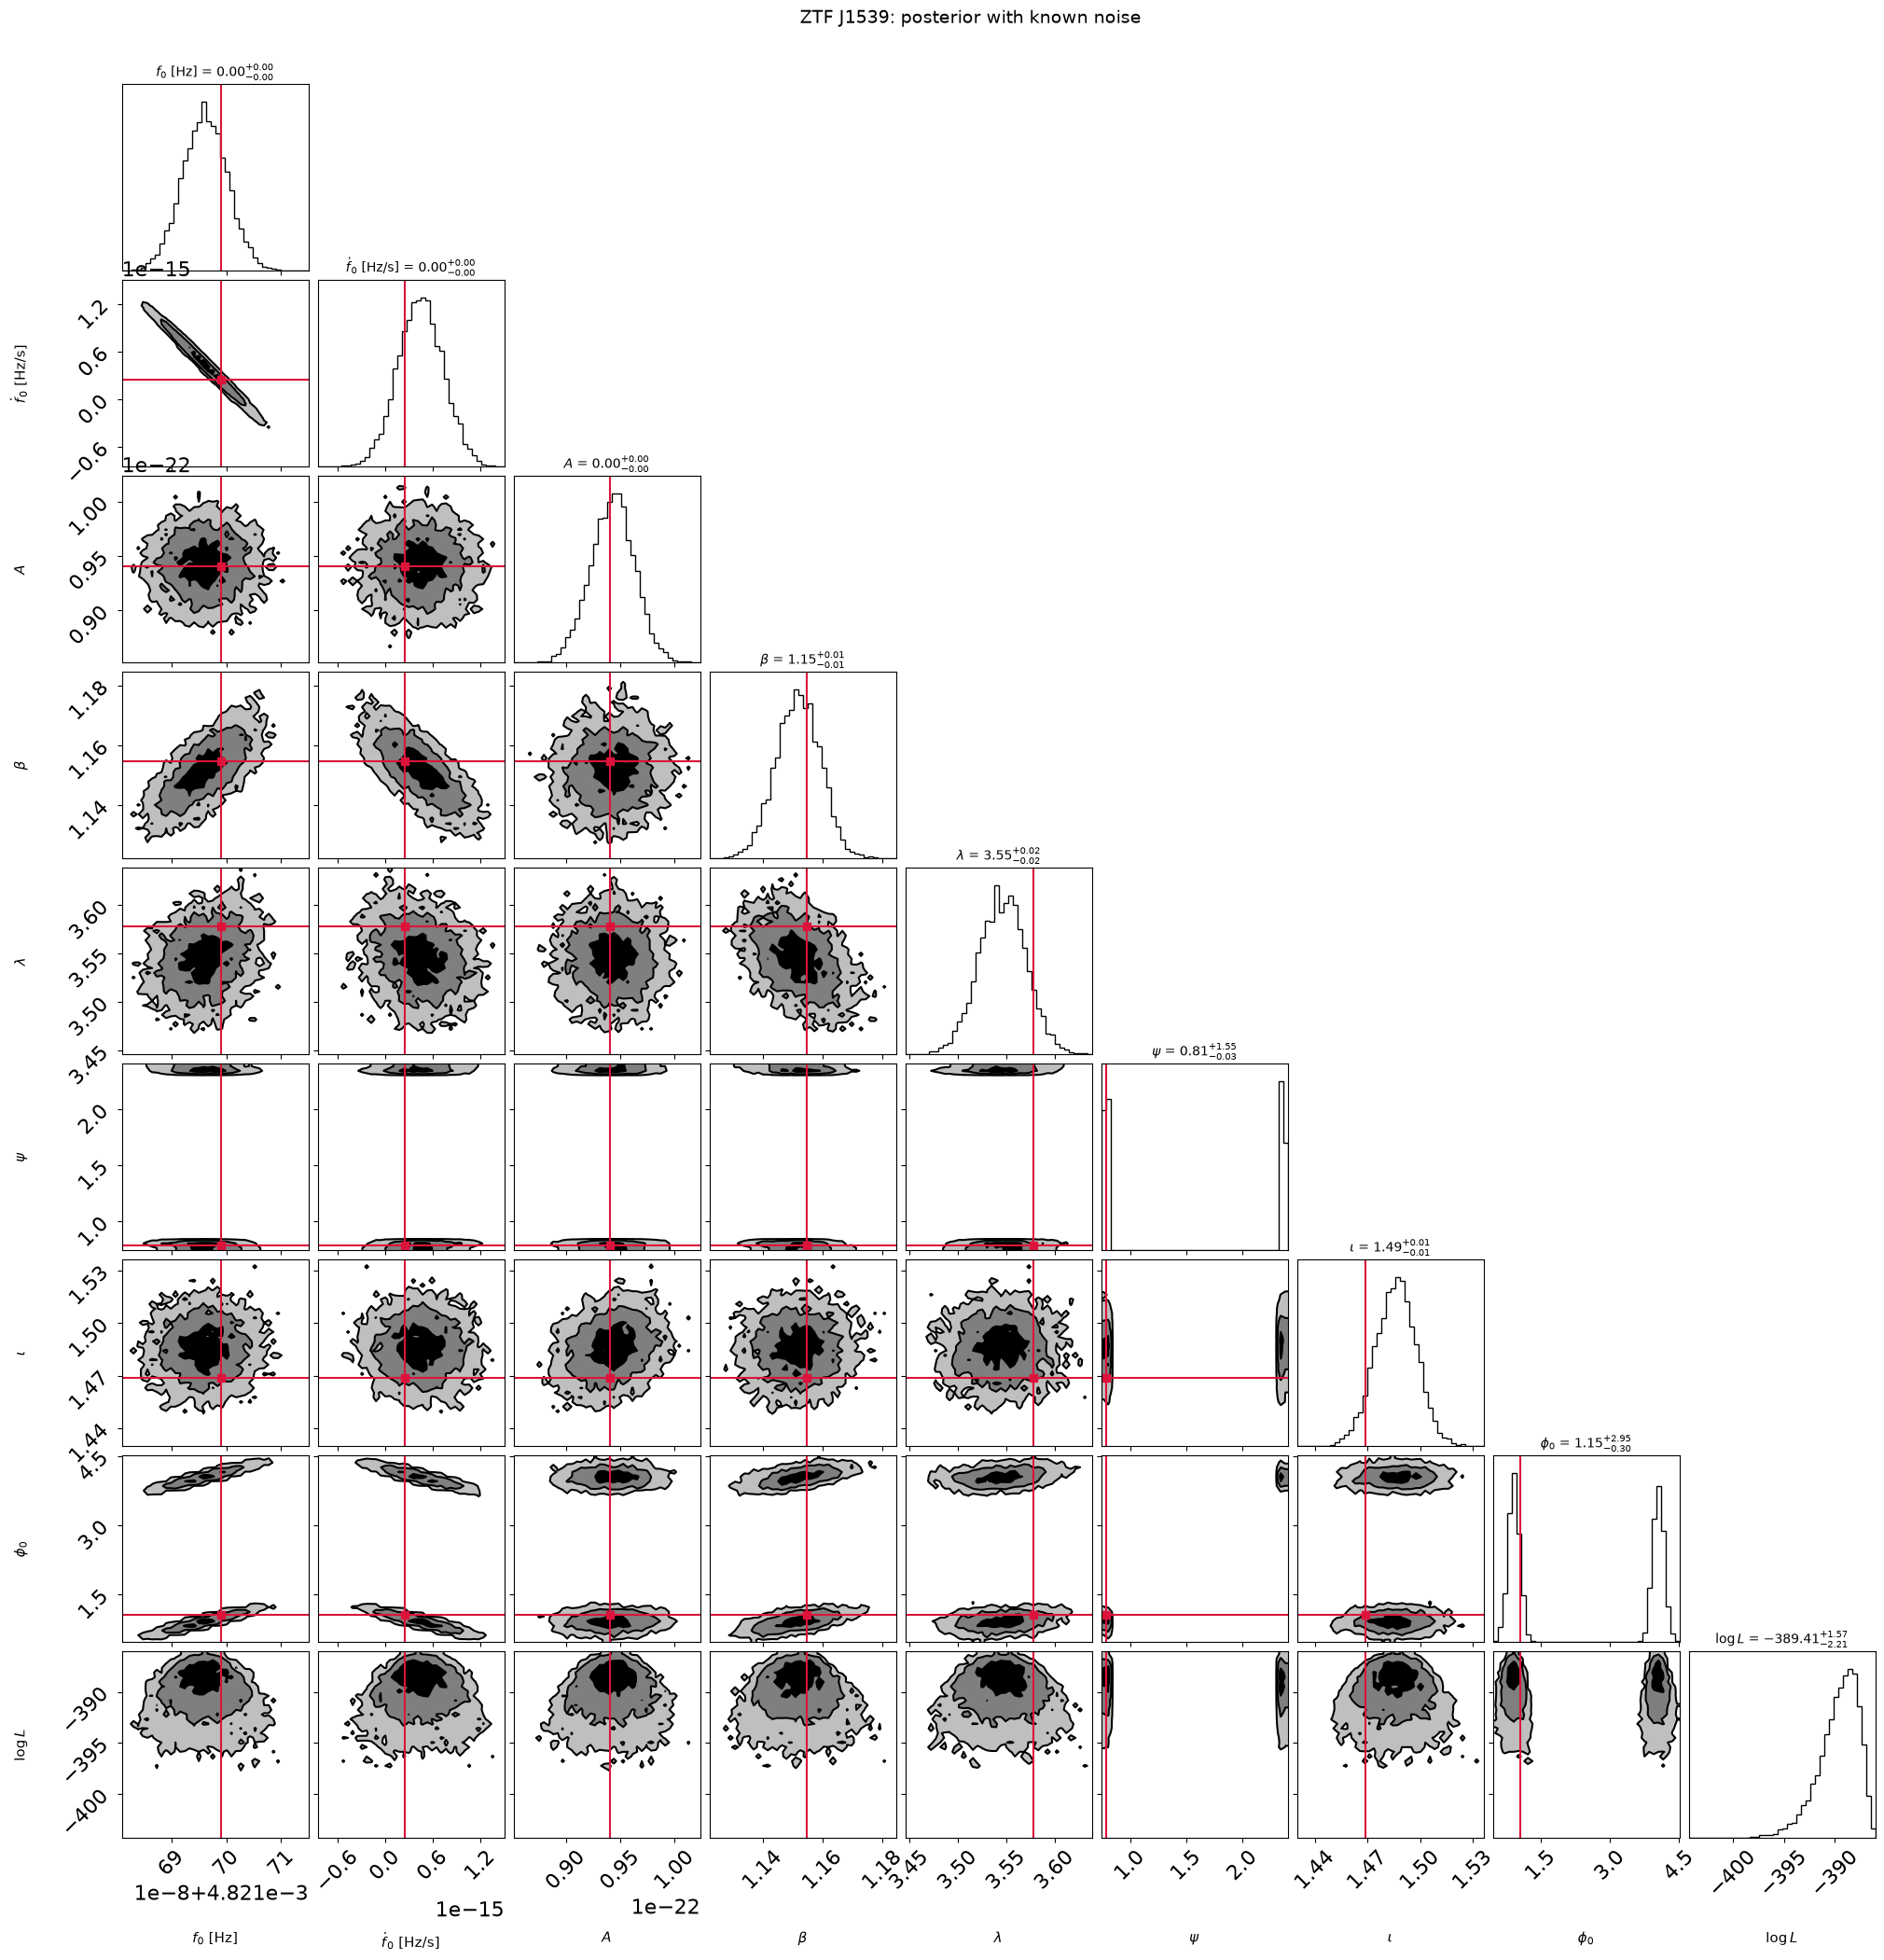

In [57]:
plot_posterior(samples, logl, truth, labels, f"{SOURCE_NAME}: posterior with known noise")

**Questions.**

* Which parameters are measured best? Compare the precision with which we can estimate the parameters and the bias using `samples, logl, truth`.
* Do you see correlations? Which ones are degeneracies of the signal (e.g. $\mathscr{A}$ vs $\cos\iota$; $\phi_0\to\phi_0+\pi$ with $\psi\to\psi+\pi/2$)? Modify `indices=[0, 2]` in the following to inspect.
* Is $\dot f_0$ measured? What would that give us astrophysically?
* Could you use the Gaia measurements to improve these estimates or break degeneracies? How would you do that?

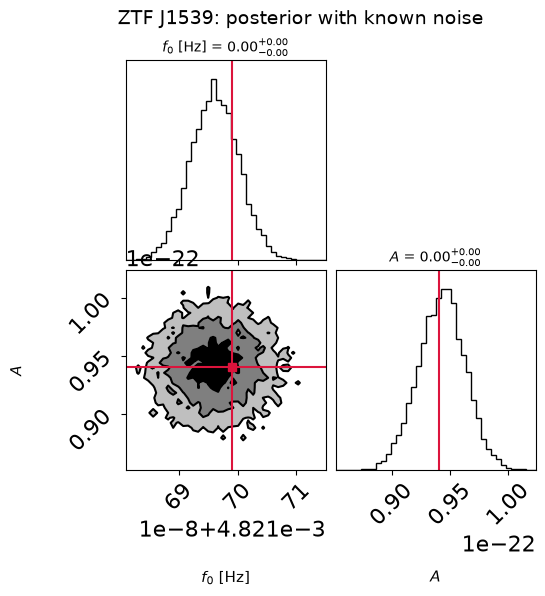

In [58]:
plot_posterior(samples, logl, truth, labels, f"{SOURCE_NAME}: posterior with known noise", indices=[0, 2])

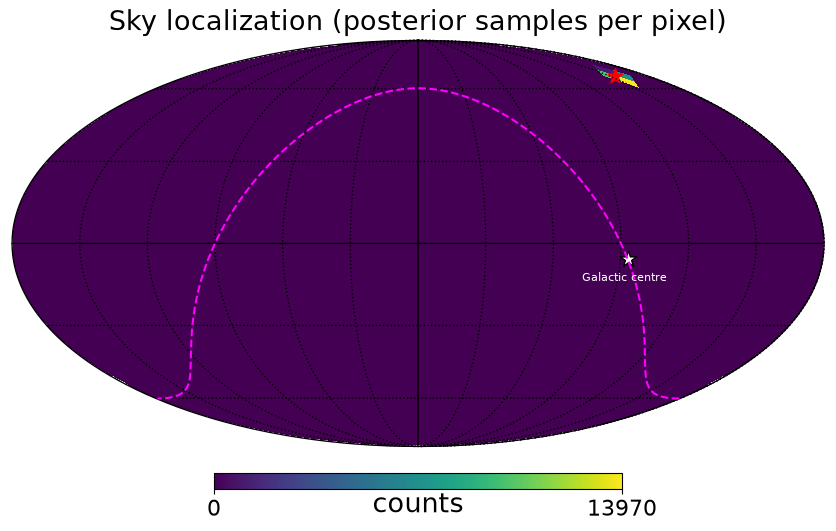

In [59]:
counts = samples_to_sky_counts(samples, nside=16)
plot_sky_map(counts, "Sky localization (posterior samples per pixel)", "counts", truth=truth_sky)

# Exercise

* Set `SOURCE_NAME` to another verification binary (e.g. `"ZTF J1539"` or `"ES Cet"`) and re-run everything below and compare sources. Do the results meet your expectation?
* Change the observation time `tobs` and check how the results change.

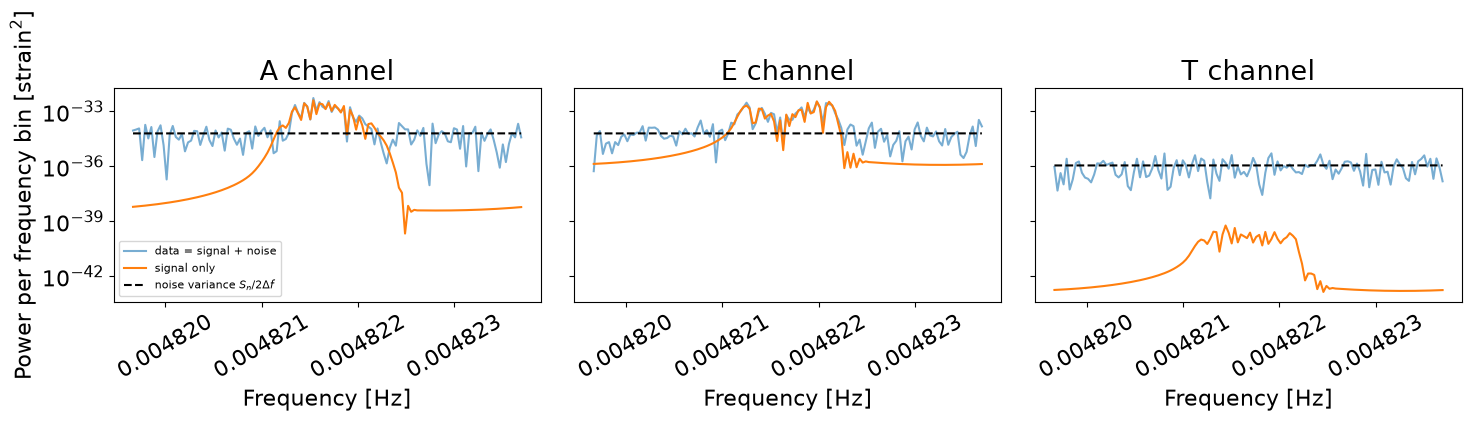

In [69]:
# FILL

SOURCE_NAME = "ZTF J1539"
source_params = get_source(SOURCE_NAME)

# Set the source parameters
tobs = 365 * 86400  # 365 days
analysis = GBAnalysis(source_params,tobs=tobs)
print(analysis)

# plot data
# plt.plot(tobs, analysis)
analysis.plot_data()


# plot SNR

# Bayesian analysis: MCMC sampling of the posterior distribution

# Extra: Fitting signal and noise

Now the noise variance is unknown, so we infer it alongside the source parameters. We use a deliberately **simplified** model: in each channel $X\in\{A,E,T\}$ the noise is white (frequency-independent) and uncorrelated between channels,

$$\mathbb{E}[|n_{X,k}|^2]=\sigma_X^2,\qquad \mathbf{Cov}_{\rm model}=\mathrm{diag}(\sigma_A^2,\sigma_E^2,\sigma_T^2).$$

As in Eq. A7 of [Muratore et al. 2023](https://arxiv.org/pdf/2308.01056), the frequency bins are independent and the real and imaginary parts of each residual $r_{X,k}=d_{X,k}-h_{X,k}(\boldsymbol\theta)$ are Gaussian, each with variance $\sigma_X^2/2$. The log-likelihood is the sum over the $N_{\rm freq}$ bins of the log of this Gaussian:

$$\ln p(d|\boldsymbol\theta,\boldsymbol\sigma)=-\sum_{X}\sum_{k=1}^{N_{\rm freq}}\left[\ln\!\left(\pi\sigma_X^2\right)+\frac{|r_{X,k}|^2}{\sigma_X^2}\right].$$

The first term is the normalization (the determinant of the covariance). It must be kept when $\sigma_X$ is fitted, otherwise the likelihood would favour arbitrarily large noise. The injected noise is coloured and can have small cross-channel correlations, so this model is intentionally approximate: we use it to see how an imperfect noise model affects the source posterior.

ln L at [truth, sigma0]       : 29928.342438670945
analytic expectation (approx) : 29934.856556887204
ln L, f0 off by 20 bins       : 27693.604847412666


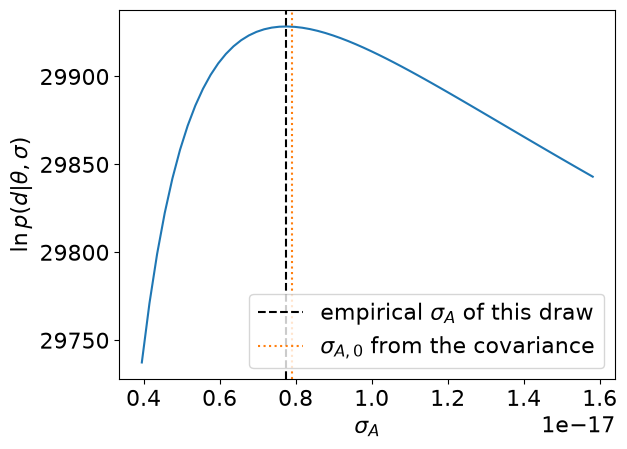

In [61]:
loglike_n = analysis.make_log_likelihood(fit_noise=True)
truth_n = np.concatenate([analysis.source_params, analysis.sigma0])

print("ln L at [truth, sigma0]       :", loglike_n(truth_n)[0])
print("analytic expectation (approx) :", -np.sum(analysis.n_bins * (np.log(np.pi * analysis.sigma0**2) + 1)))
shifted_n = truth_n.copy(); shifted_n[0] += 20 * analysis.df
print("ln L, f0 off by 20 bins       :", loglike_n(shifted_n)[0])

grid = np.linspace(0.5, 2, 60) * analysis.sigma0[0]
pts = np.repeat(truth_n[None], len(grid), axis=0); pts[:, 8] = grid
plt.plot(grid, loglike_n(pts))
plt.axvline(analysis.sigma_empirical[0], color="k", ls="--", label=r"empirical $\sigma_A$ of this draw")
plt.axvline(analysis.sigma0[0], color="C1", ls=":", label=r"$\sigma_{A,0}$ from the covariance")
plt.xlabel(r"$\sigma_A$"); plt.ylabel(r"$\ln p(d|\theta,\sigma)$"); plt.legend(); plt.show()

In [62]:
priors_n, periodic_n, ndims_n, bounds_n = make_priors(
    analysis.source_params[0], 1e-6, A_center=analysis.source_params[2], sigma0=analysis.sigma0)

tic = time.time()
sampler_n = run_gb_mcmc(loglike_n, priors_n, periodic_n, ndims_n, bounds_n, truth_n,
                        nwalkers=NWALKERS, ntemps=NTEMPS, n_iterations=N_ITER, burn=N_BURN)
print(f"MCMC finished in {time.time() - tic:.0f} s")

samples_n, logl_n = get_cold_samples(sampler_n)
labels_n = get_parameter_labels(include_noise=True)
summarize_posterior(samples_n, truth_n, labels_n)

100%|██████████| 2000/2000 [01:33<00:00, 21.34it/s]

MCMC finished in 117 s
Parameter          | Median             | Std          | Precision  | Bias         | Bias (sigma)
----------------------------------------------------------------------------------------------------
$f_0$ [Hz]         | 4.8216964406e-03   | 4.3464e-09   | 9.01e-07   | -2.6666e-09  | -0.61
$\dot f_0$ [Hz/s]  | 4.1168066339e-16   | 3.0209e-16   | 1.19e+00   | 1.5790e-16   | +0.52
$A$                | 9.4362880992e-23   | 2.1396e-24   | 2.28e-02   | 3.3873e-25   | +0.16
$\beta$            | 1.1524490741e+00   | 8.1615e-03   | 7.07e-03   | -2.2886e-03  | -0.28
$\lambda$          | 3.5479017171e+00   | 2.4565e-02   | 6.86e-03   | -3.0505e-02  | -1.24
$\psi$             | 8.0103011241e-01   | 7.7834e-01   | 9.91e-01   | 1.5632e-02   | +0.02
$\iota$            | 1.4865172381e+00   | 1.2260e-02   | 8.35e-03   | 1.7823e-02   | +1.45
$\phi_0$           | 1.0817925969e+00   | 1.5614e+00   | 1.49e+00   | 3.4595e-02   | +0.02
$\sigma_A$         | 7.8114053675e-18   | 3.3586e-

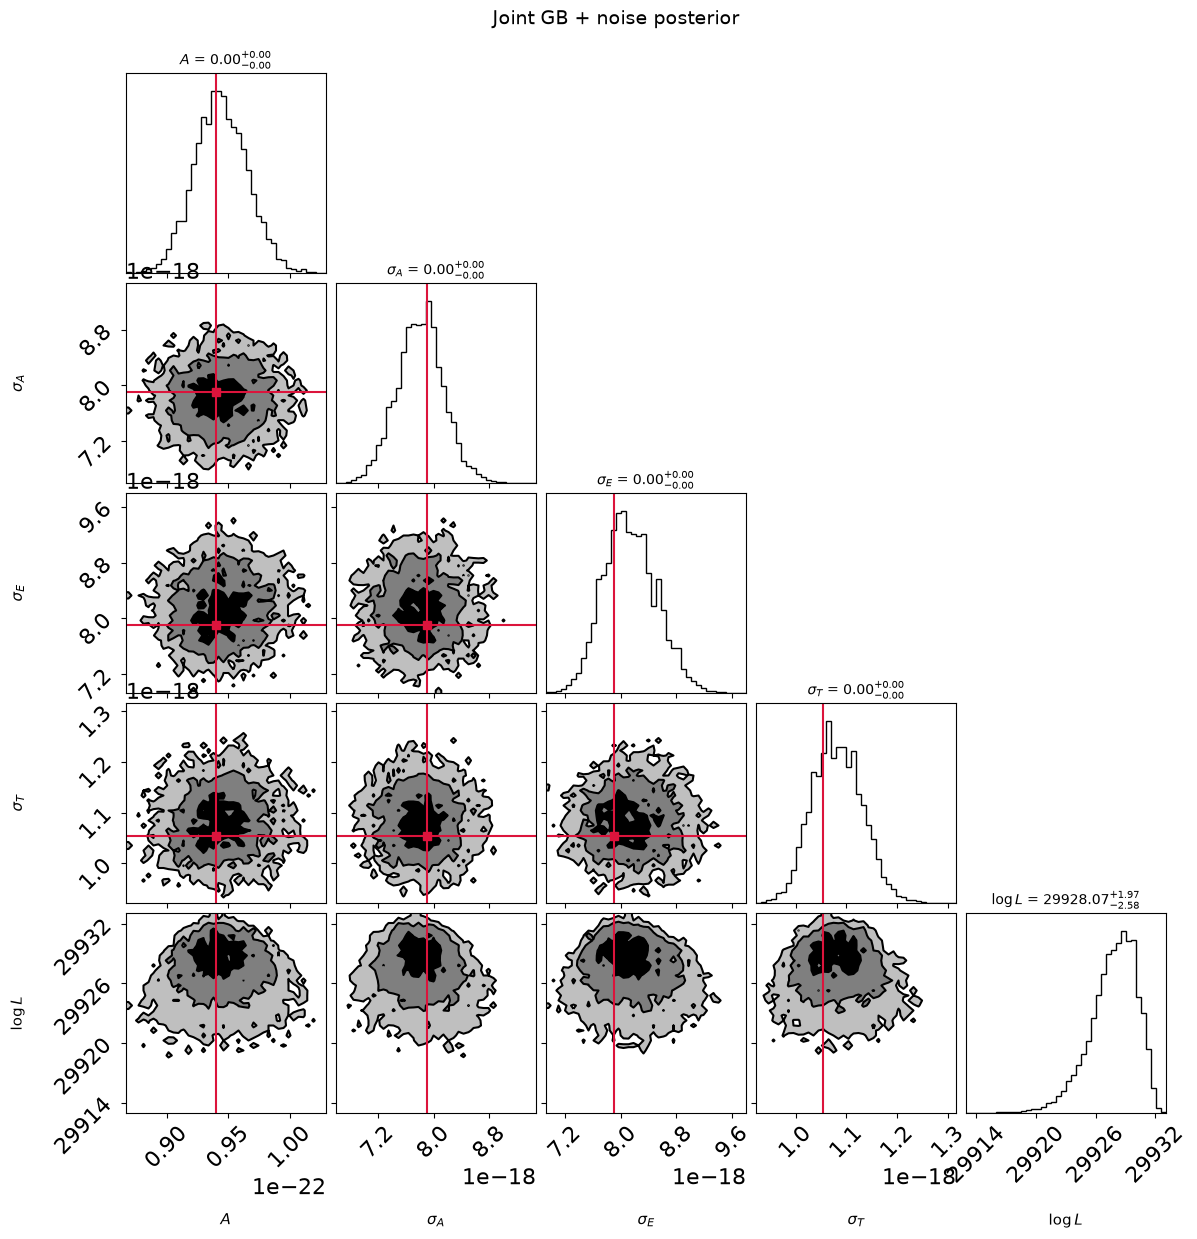

In [63]:
plot_posterior(samples_n, logl_n, truth_n, labels_n, "Joint GB + noise posterior", indices=[2, 8, 9, 10, 11])

## Does fitting the noise change the source parameters?
What would we expect to change?

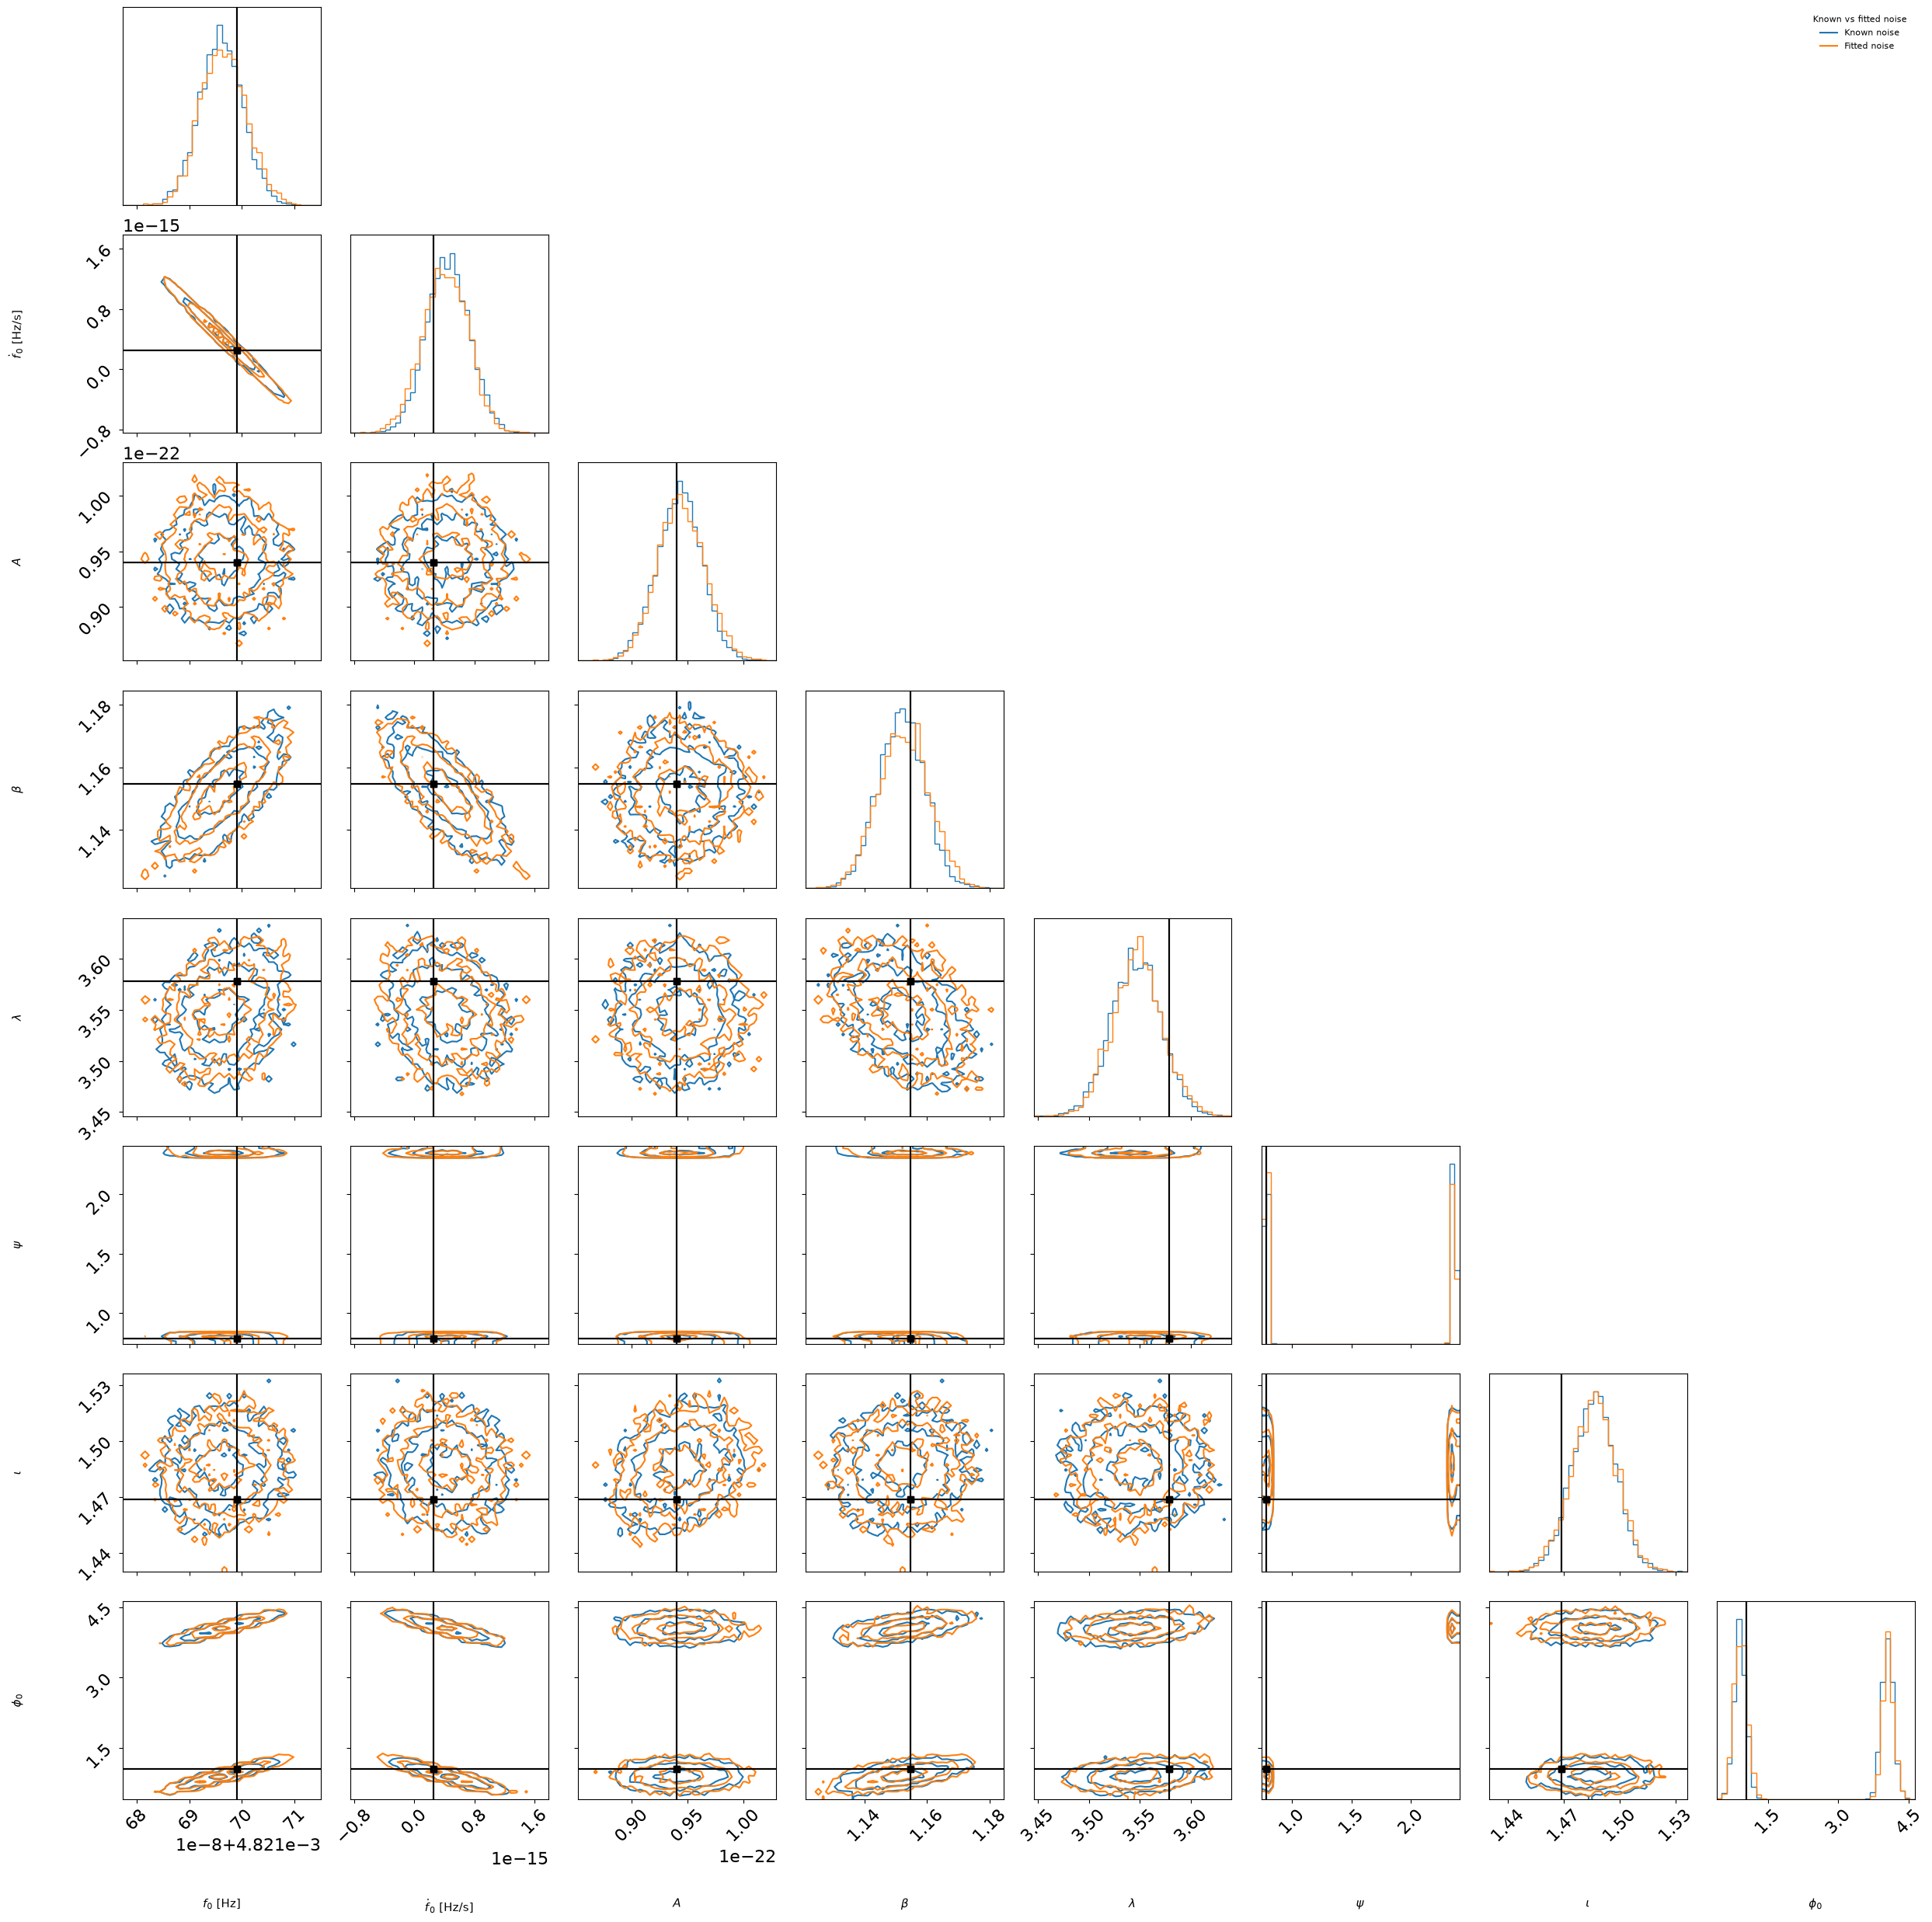

In [64]:
CORNER_OVERLAY = dict(
    labels=get_parameter_labels(), truths=truth, bins=40,
    levels=(1 - np.exp(-0.5), 1 - np.exp(-2), 1 - np.exp(-9 / 2.0)),
    plot_density=False, plot_datapoints=False, fill_contours=False, max_n_ticks=4,
    truth_color="k", labelpad=0.2, label_kwargs=dict(fontsize=11))
overlaid_corner([samples, samples_n[:, :8]], ["Known noise", "Fitted noise"],
                corn_kw=CORNER_OVERLAY, title="Known vs fitted noise")

# Appendix: From polarizations to the detector output

## From $h_+$ and $h_\times$ to TDI data

A binary emits two transverse polarizations. For the circular-binary convention used in this tutorial,

$$h_+(t)=\mathscr{A}(1+\cos^2\iota)\cos\Phi(t),\qquad
h_\times(t)=2\mathscr{A}\cos\iota\sin\Phi(t).$$

These are not yet the data measured by LISA. Each directed laser link measures a fractional-frequency shift. The passing wave changes the light travel time, and therefore the received laser frequency. The response depends on link direction, sky position, spacecraft motion and light travel time. In the frequency domain we can summarize one link's response as

$$\tilde y_\ell(f)=R_{\ell+}(f)\tilde h_+(f)+R_{\ell\times}(f)\tilde h_\times(f),$$

where $\ell$ labels one of the six directed links. The response factors include propagation delays and the finite-arm response; they are not just a constant projection of $h_+$ or $h_\times$.

The derivation below gives the explicit time-domain form of $R_{\ell A}(f)$ for a plane wave.
### Derivation: photon geodesic in a plane gravitational wave

We derive the link response from first principles to first order in $h$ (units $G=c=1$; restore $c$ via $L\to L/c$). In TT gauge,

$$ds^2=-dt^2+\left(\delta_{ij}+h_{ij}(u)\right)dx^i dx^j,\qquad u=t-\hat k\cdot\mathbf x,\qquad \hat k^i h_{ij}=0,\quad h_{ii}=0,$$

with $\hat k$ the direction of wave propagation. Free-falling spacecraft keep fixed TT coordinates ($\Gamma^i_{00}=0$). Take a link with emitter at $\mathbf x_s$, receiver at $\mathbf x_r$, $L=|\mathbf x_r-\mathbf x_s|$ and $\hat n=(\mathbf x_r-\mathbf x_s)/L$ pointing emitter $\to$ receiver.

**1. Geodesic equation.** For the photon wave vector $p^\mu=dx^\mu/d\lambda$, $p_\mu=g_{\mu\nu}p^\nu$,

$$\frac{dp_\mu}{d\lambda}=\tfrac12\,\partial_\mu g_{\alpha\beta}\,p^\alpha p^\beta .$$

Since $h_{ij}$ depends only on $u$, $\partial_t h_{ij}=\dot h_{ij}$ and $\partial_k h_{ij}=-\hat k_k\dot h_{ij}$ (dot $=d/du$), so

$$\frac{dp_0}{d\lambda}=\tfrac12\dot h_{ij}p^ip^j,\qquad \frac{dp_k}{d\lambda}=-\hat k_k\,\frac{dp_0}{d\lambda}.$$

With $E\equiv-p_0=p^0$ (the frequency seen by a spacecraft at rest in TT coordinates, because $g_{00}=-1$, $g_{0i}=0$) this gives three exact constants of motion:

$$p_k-\hat k_k E=\text{const}.$$

**2. Frequency shift.** At zeroth order the ray is $p^\mu=E_s(1,\hat n)$, $\mathbf x(t)=\mathbf x_s+\hat n\,(t-t_s)$, hence $u(t)=u_s+(1-\hat k\cdot\hat n)(t-t_s)$ and along the ray
$\dfrac{d}{dt}h_{ij}(u(t))=(1-\hat k\cdot\hat n)\,\dot h_{ij}$. Inserting into $dE/dt=-\tfrac12\dot h_{ij}p^ip^j/E$ and keeping first order,

$$\frac{dE}{dt}=-\frac{E_s}{2}\,\frac{n^in^j}{1-\hat k\cdot\hat n}\,\frac{d h_{ij}(u(t))}{dt}
\;\Rightarrow\;
E(t)=E_s\left[1-\frac{n^in^j}{2(1-\hat k\cdot\hat n)}\big(h_{ij}(u(t))-h_{ij}(u_s)\big)\right].$$

**3. The perturbed ray.** Using $p^i=p_i-h_{ij}p^j$ and $\Delta(t)\equiv E(t)/E_s-1$,

$$\frac{dx^i}{dt}=\frac{p^i}{p^0}=n^i+\beta^i+(\hat k^i-n^i)\,\Delta(t)+n^j\left[h_{ij}(u_s)-h_{ij}(u(t))\right],$$

where the constant $\beta^i$ (first-order change of the launch direction) is fixed by requiring $\mathbf x(t_r)=\mathbf x_r$. With $H_{ij}(u)=\int^u h_{ij}\,du'$ one has $\int h_{ij}(u(t))\,dt=H_{ij}/(1-\hat k\cdot\hat n)$, so the integration is explicit.

**4. Light travel time.** The null condition gives $dt=|d\mathbf x|\,\big(1+\tfrac12h_{ij}n^in^j\big)+O(h^2)$. For fixed endpoints the Euclidean length of the perturbed path differs from $L$ only at $O(h^2)$, so the ray deflection of step 3 does not contribute and

$$t_r-t_s=L+\frac{n^in^j}{2(1-\hat k\cdot\hat n)}\Big[H_{ij}(u_r)-H_{ij}(u_s)\Big],\qquad u_s=t_s-\hat k\cdot\mathbf x_s,\;\;u_r=t_r-\hat k\cdot\mathbf x_r,$$

and at the order needed $u_r-u_s=L(1-\hat k\cdot\hat n)$. Differentiating with respect to $t_s$ and using $\nu_r/\nu_s=dt_s/dt_r$ reproduces step 2, a consistency check.

**5. Result: one-way fractional frequency shift.**

$$\boxed{\;y_{sr}(t_r)\equiv\frac{\nu_r-\nu_s}{\nu_s}=-\frac{n^in^j}{2\,(1-\hat k\cdot\hat n)}\Big[h_{ij}\big(t_r-\hat k\cdot\mathbf x_r\big)-h_{ij}\big(t_r-L-\hat k\cdot\mathbf x_s\big)\Big]\;}$$

Sanity check: for $\hat k\perp\hat n$ and slowly varying $h$, $y\approx-\tfrac12 L\,\dot h_{nn}$, the familiar expansion of space ($\nu_r/\nu_s=a_s/a_r$).
The spacecraft orbital velocity adds the usual kinematic Doppler shift (independent of $h$ at first order, removed by TDI) and makes $\mathbf x_{s,r}$, $\hat n$ and $L$ time dependent; they are evaluated at emission and reception.
$y$ is defined with the sign convention $(\nu_r-\nu_s)/\nu_s$; other references flip the sign.

**6. Explicit form.** Choose $\hat p,\hat q\perp\hat k$ with $e^+=\hat p\hat p-\hat q\hat q$, $e^\times=\hat p\hat q+\hat q\hat p$, so $h_{ij}=h_+e^+_{ij}+h_\times e^\times_{ij}$ and

$$n^in^jh_{ij}=\xi_+h_++\xi_\times h_\times,\qquad \xi_+=(\hat n\!\cdot\!\hat p)^2-(\hat n\!\cdot\!\hat q)^2,\quad \xi_\times=2(\hat n\!\cdot\!\hat p)(\hat n\!\cdot\!\hat q).$$

Since $\xi_+^2+\xi_\times^2=\big(1-(\hat k\cdot\hat n)^2\big)^2$, the factor $1/(1-\hat k\cdot\hat n)$ never diverges. In the frequency domain ($h(t-a)\to e^{-2\pi i f a}\tilde h$) the link responses of the previous paragraph are

$$R_{\ell A}(f)=-\frac{\xi_A}{2(1-\hat k\cdot\hat n)}\,e^{-2\pi i f\,\hat k\cdot\mathbf x_r}\Big[1-e^{-2\pi i fL(1-\hat k\cdot\hat n)}\Big],\qquad A\in\{+,\times\}.$$

For the binary, $h_+=\mathscr A(1+\cos^2\iota)\cos\Phi(u)$, $h_\times=2\mathscr A\cos\iota\sin\Phi(u)$. Neglecting $\dot f_0$ over one light-travel time, $\Phi(u_r)-\Phi(u_s)=2\pi f_0L(1-\hat k\cdot\hat n)$, and the bracket in the boxed formula collapses to a sinc:

$$y_{sr}(t_r)=\pi f_0L\;\mathrm{sinc}\!\big[\pi f_0L(1-\hat k\cdot\hat n)\big]\;\mathscr A\Big[\xi_+(1+\cos^2\iota)\sin\Phi_m-2\xi_\times\cos\iota\,\cos\Phi_m\Big],$$

with $\mathrm{sinc}\,x=\sin x/x$ and $\Phi_m=\Phi(u_m)$ the phase at the link midpoint, $u_m=t_r-\tfrac{L}{2}-\hat k\cdot\tfrac{\mathbf x_r+\mathbf x_s}{2}$.

* **Long-wavelength limit** ($2\pi f_0L\ll1$): $\mathrm{sinc}\to1$ and $y\to-\tfrac L2\,\partial_t(n^in^jh_{ij})$, so the response grows $\propto f_0L$; the full sinc is the finite-arm correction (transfer frequency $f_*=1/2\pi L$).
* **Directions**: reversing the link ($\hat n\to-\hat n$) keeps $\xi_{+,\times}$ but changes $1-\hat k\cdot\hat n\to1+\hat k\cdot\hat n$, so the six directed links respond differently.

*Check performed:* the first-order formulas (frequency shift, travel-time delay, and the sinc closed form) were compared with a direct numerical integration of the full geodesic equations in the plane-wave metric. The discrepancy scales as $h^2$, as expected for a first-order result.

# Further Reading and Resources

### Gravitational-wave data analysis

* **Finn (1992)** — *Detection, Measurement and Gravitational Radiation*
  One of the foundational papers on GW data analysis. Introduces the statistical formulation of detection and parameter estimation in noisy data, including likelihoods and parameter-confidence regions.
  [arXiv:gr-qc/9209010](https://arxiv.org/abs/gr-qc/9209010)

* **Jaranowski & Królak (2012)** — *Gravitational-Wave Data Analysis. Formalism and Sample Applications: The Gaussian Case*
  A comprehensive introduction to matched filtering, likelihoods, signal-to-noise ratios, Fisher matrices, and detection statistics.
  [arXiv:0711.1115](https://arxiv.org/abs/0711.1115)

* **Thrane & Talbot (2019)** — *An introduction to Bayesian inference in gravitational-wave astronomy: parameter estimation, model selection, and hierarchical models*
  A practical introduction to Bayesian parameter estimation and model selection in GW astronomy.
  [arXiv:1809.02293](https://arxiv.org/abs/1809.02293)

* **IMPRS for Gravity at the Extreme — Lecture Series**  
  A collection of lecture courses from the Max Planck Institute for Gravitational Physics (AEI), covering gravitational-wave theory and source modelling, gravitational-wave data analysis, computational physics, and compact-object astrophysics. Includes lecture material, recordings, and problem sets where available.  
  [IMPRS Lectures](https://imprs-lectures.aei.mpg.de/)

* **Speri et al. (2022)** — *A roadmap of gravitational wave data analysis*
  A broad overview of modern GW data-analysis methods, from signal processing and inference to computational techniques.
  [2022NatAs...6.1356S](https://ui.adsabs.harvard.edu/abs/2022NatAs...6.1356S/abstract)


### Hands-on tutorials and further resources

- **Ollie Burke — Tutorials**  
  A collection of hands-on tutorials and Jupyter notebooks covering gravitational-wave and LISA data analysis.  
  [GitHub](https://github.com/OllieBurke/Tutorials)

- **LISA Analysis Tools Workshop (LATW)**  
  Hands-on LISA data-analysis tutorials covering inner products, SNRs, likelihoods, LISA response, EMRIs, MCMC/RJMCMC, and Galactic binaries.  
  [GitHub](https://github.com/lisa-analysis-tools/LATW)

- **Gravitational-Wave Open Data Workshop (GW-ODW)**  
  Interactive notebooks introducing the complete GW data-analysis workflow, from accessing public data to signal processing, searches, and parameter estimation.  
  [GitHub](https://github.com/gw-odw/odw)

- **GWOSC — Introduction to GWOSC Data**  
  Practical notebooks covering GW data access, file formats, quality flags, Fourier-domain analysis, and GWpy.  
  [GitHub](https://github.com/gwosc-tutorial/introduction_gwosc_data)

- **GWOSC — Data Guide Notebook**  
  Hands-on examples of windowing, Fourier transforms, PSD estimation, likelihood maximization, correlations, and residual analysis.  
  [GitHub](https://github.com/gwosc-tutorial/Data_Guide) · [Paper](https://arxiv.org/abs/1908.11170)

- **PyCBC Tutorials**  
  Tutorials on accessing GW data, signal processing, matched filtering, detection significance, and parameter estimation.  
  [GitHub](https://github.com/gwastro/PyCBC-Tutorials)

- **J. Kanner — Introduction to Gravitational-Wave Data Analysis**  
  A collection of introductory notebooks and tutorials covering gravitational-wave data, Fourier transforms, whitening, filtering, and basic signal processing.  
  [GitHub](https://github.com/jkanner/gw-intro)